# Problem statement: Predicting Insurance price charged to the customer
### In order to make the profit, insurance companies must collect a higher premium than the amount which may become due to the insured person. To achieve this, insurance companies invest a lot of time, effort, and money in creating models that accurately predict healthcare expenses.

## Data 
**Attribute information**

| Column | Description |
|---|---|
| age | Age of primary beneficiary |
| sex | Gender: male / female |
| bmi | Body Mass Index (kg/m²) |
| children | Number of dependents covered |
| smoker | Smoking status: yes / no |
| region | Residential area in the US (northeast, northwest, southeast, southwest) |
| charges | **Target** — individual medical costs billed by insurance |


## 1. Data Collection

### importing required libraries

In [75]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [76]:
# Modelling
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

In [77]:
import joblib

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

In [78]:
df = pd.read_csv("insurance.csv")
print("shape: ", df.shape)
df.head()

shape:  (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Exploratory Data Analysis 

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [80]:
print("Missing values: ", df.isnull().sum().sum())
print("Missing values per column:")
print(df.isnull().sum())

Missing values:  0
Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [81]:
print("Duplicate rows: ", df.duplicated().sum())

Duplicate rows:  1


In [82]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(1337, 7)

### Perform statistical analysis

### numerical features

In [83]:
df.describe() # display summary statistics for numerical columns

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [84]:
df.describe(include='object') # display summary statistics for categorical columns

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


### distibution of numerical features

<Axes: xlabel='children', ylabel='Count'>

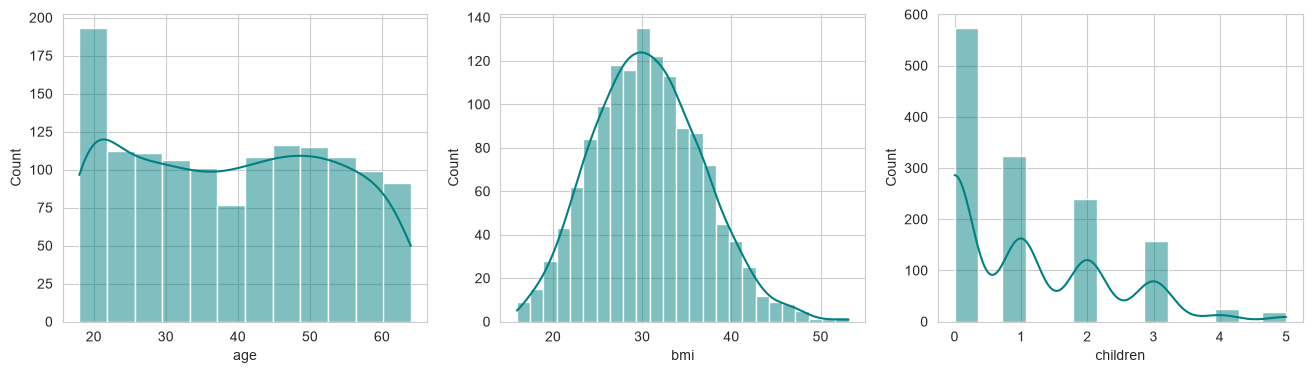

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['age'], kde=True, ax=axes[0],color='teal')
sns.histplot(df['bmi'], kde=True, ax=axes[1], color='teal')
sns.histplot(df['children'], kde=True, ax=axes[2], color='teal')

### Age distribution
- `Observation`: The age lies in range between 18 - 64, major no of individuals are found around 18 - 20, remaining age group are evenly distributed without severe imbalance.
- `business insight` : since customers are well distributed across all ages, model can learn healthcare expenditure patterns across all ages.
- `ML insight` : since there is no skewness, no transformation is required for model training.

### BMI distribution
- `Observation` : from the graph it is observed that bmi is distributed around 15 - 54 and it is normally distributed betweeen this range without any much skewness.
- `business insight` : 

### distribution of categorical features

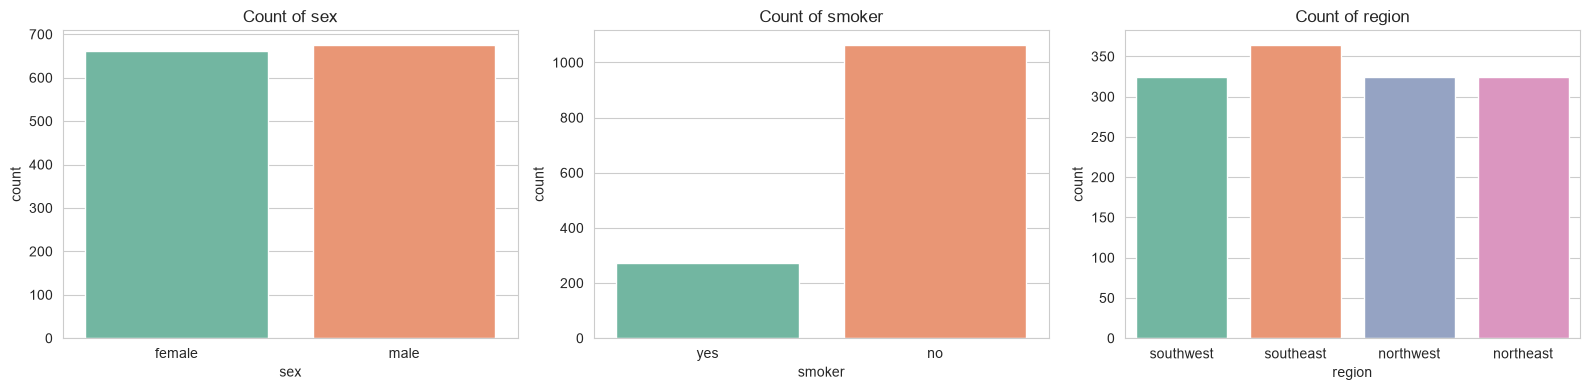

sex
male      0.505
female    0.495
Name: proportion, dtype: float64 

smoker
no     0.795
yes    0.205
Name: proportion, dtype: float64 

region
southeast    0.272
southwest    0.243
northwest    0.242
northeast    0.242
Name: proportion, dtype: float64 



In [86]:
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=df[col], ax=ax, palette='Set2')
    ax.set_title(f'Count of {col}')
plt.tight_layout()
plt.show()

for col in cat_cols:
    print(df[col].value_counts(normalize=True).round(3), "\n")


### Target variable distribution

Skewness of charges:  1.515


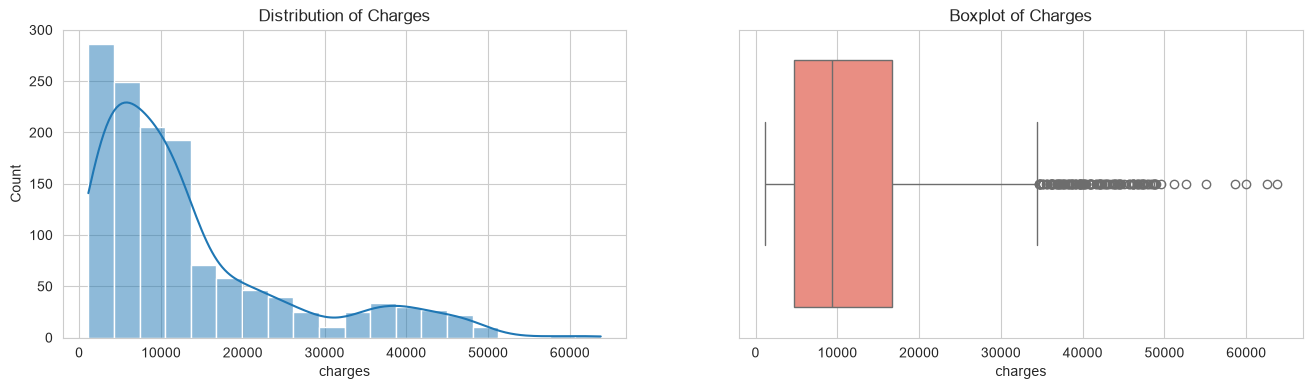

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(df['charges'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Charges')
sns.boxplot(x=df['charges'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Charges')

print("Skewness of charges: ", df['charges'].skew().round(3))



### Relationship between features and charges

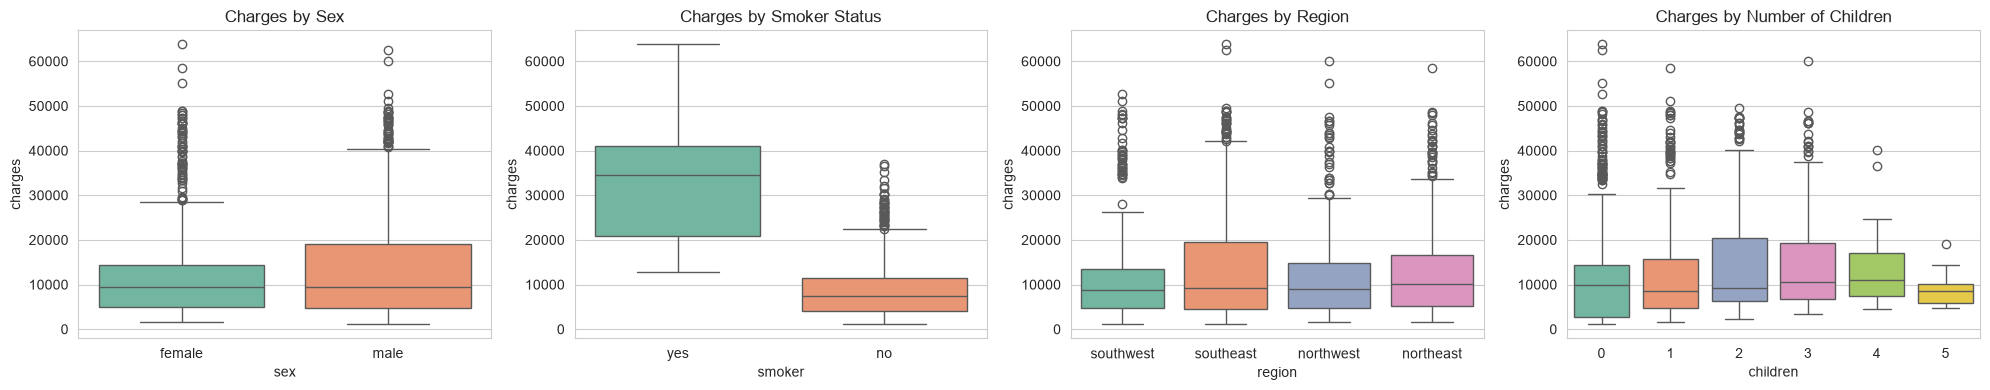

In [88]:
fig, axes = plt.subplots(1,4, figsize=(20,4))
sns.boxplot(x= 'sex',y = 'charges',data = df, ax = axes[0],palette='Set2')
axes[0].set_title('Charges by Sex')
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[1],palette='Set2')
axes[1].set_title('Charges by Smoker Status')
sns.boxplot(x='region',y='charges', data = df, ax = axes[2], palette='Set2')
axes[2].set_title('Charges by Region')
sns.boxplot(x='children', y='charges', data = df, ax = axes[3], palette = 'Set2')
axes[3].set_title('Charges by Number of Children')
plt.tight_layout()
plt.show()

### Overall inference
Among these four categorical variables, only smoker status meaningfully separates the charge distributions on its own. Sex, region, and children number show largely overlapping distributions — their effect on charges, if any, is likely conditional on other variables (e.g., smoker × bmi, or age) rather than a direct main effect. This matches what showed up in feature importance from the trained models: smoker_flag and the smoker_bmi interaction dominated, while sex/region contributed comparatively little.

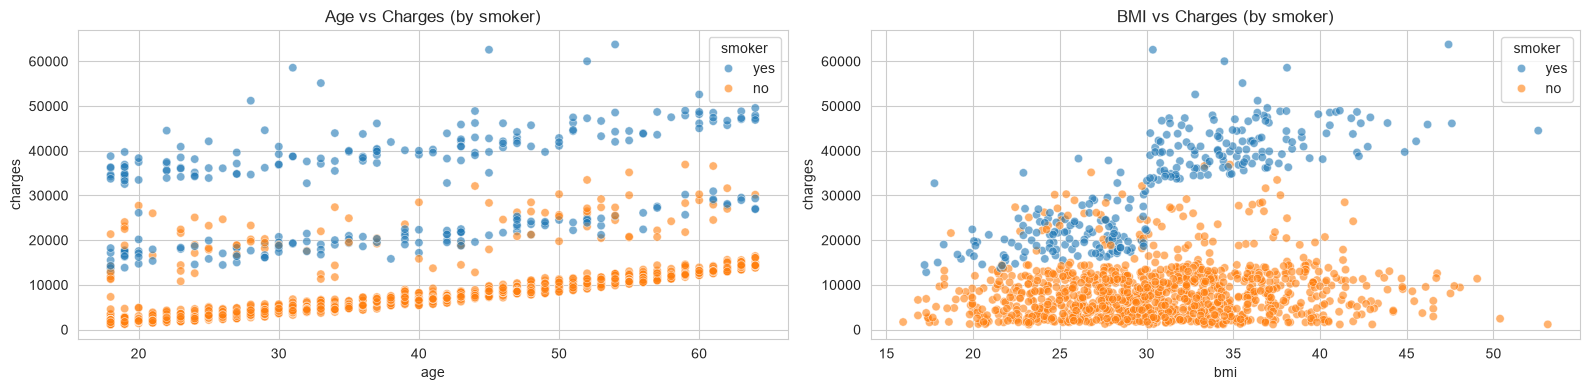

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Age vs Charges (by smoker)')
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1], alpha=0.6)
axes[1].set_title('BMI vs Charges (by smoker)')
plt.tight_layout()
plt.show()

### Overall inference
Both plots confirm the same underlying story from the earlier boxplots, but now with more nuance:

Smoking status is the gatekeeper variable — it determines which "regime" a person falls into.
Age matters roughly linearly within each smoking group.
BMI matters mostly for smokers, and especially once they cross into obesity (BMI ≥ 30).

This motivates adding an explicit `smoker_bmi` interaction feature during feature engineering.

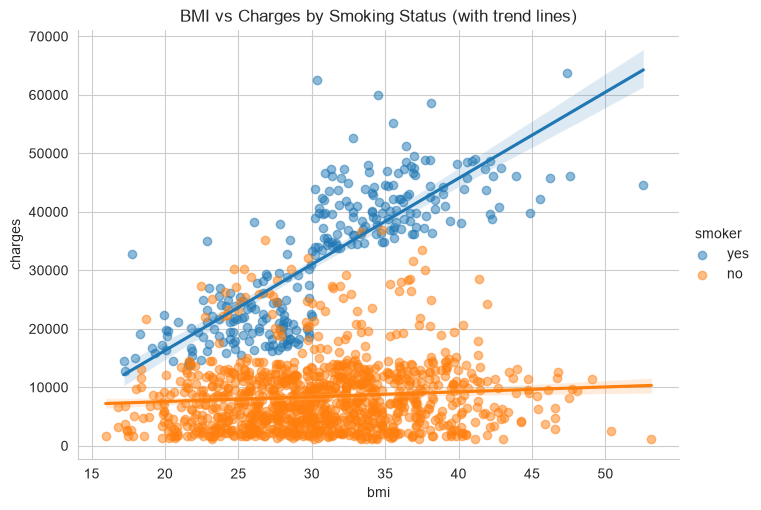

In [90]:
# Interaction view: charges vs bmi, split by smoker, colored by an obesity threshold (BMI >= 30)
tmp = df.copy()
tmp['obese'] = tmp['bmi'] >= 30
sns.lmplot(x='bmi', y='charges', hue='smoker', data=tmp, height=5, aspect=1.4, scatter_kws={'alpha':0.5})
plt.title('BMI vs Charges by Smoking Status (with trend lines)')
plt.show()

### Correlation Analysis of numerical features

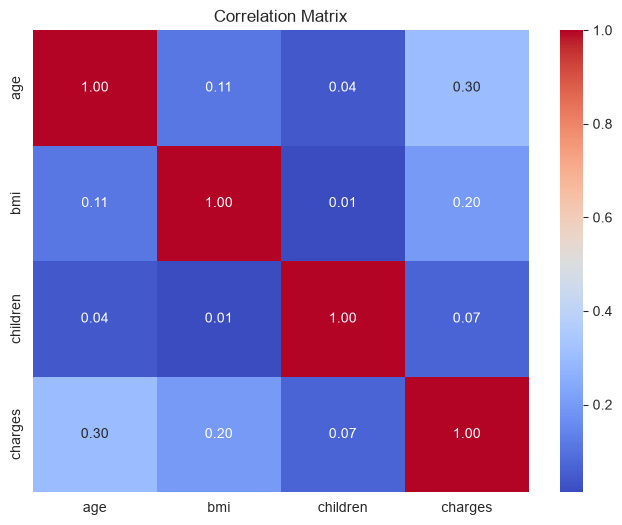

charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64

In [91]:
numeric_cols = ['age', 'bmi', 'children', 'charges']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
corr['charges'].sort_values(ascending=False)

### Outlier Detection(BMI, charges)

we can use IQR method to report outliers, we don't remove them as they are legitimate(mostly smokers/high BMI), so removing them would remove real signal the model needs to learn.

In [92]:
def iqr_outlier_detection(series):
    q1 = series.quantile(0.25)
    print("Q1 (25th percentile): ", q1.round(3))
    q3 = series.quantile(0.75)
    print("Q3 (75th percentile): ", q3.round(3))
    iqr = q3 - q1
    print("IQR: ", iqr.round(3))
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    print("Lower Bound: ", lower_bound.round(3))
    print("Upper Bound: ", upper_bound.round(3))

    return series[(series < lower_bound) | (series > upper_bound)]

for col in ['bmi', 'charges']:
    print(f'Outliers in column {col}:')
    outliers = iqr_outlier_detection(df[col])
    print(f'Number of outliers: {len(outliers)}')

Outliers in column bmi:
Q1 (25th percentile):  26.29
Q3 (75th percentile):  34.7
IQR:  8.41
Lower Bound:  13.675
Upper Bound:  47.315
Number of outliers: 9
Outliers in column charges:
Q1 (25th percentile):  4746.344
Q3 (75th percentile):  16657.717
IQR:  11911.373
Lower Bound:  -13120.716
Upper Bound:  34524.778
Number of outliers: 139


### Task 1 Report : EDA Summary

- **No missing values** in the dataset; a small number of exact duplicate rows were removed.
- `charges` is **strongly right-skewed** (skew ≈ 1.5), with a long tail of high-cost cases — mostly smokers.
- **Smoking status is the single strongest predictor** of charges: smokers pay several times more than non-smokers on average, and the gap widens further with higher BMI.
- **Age** shows a clear positive, roughly linear relationship with charges within each smoker group (three visible "bands" — likely age-related premium tiers).
- **BMI** matters much more for smokers than non-smokers — a strong `smoker × bmi` interaction effect.
- **Sex** and **region** show only minor differences in charge distributions — weak predictors on their own.
- **Children** has a weak, non-monotonic relationship with charges.
- Correlation of raw numeric features with charges is highest for `age` (~0.30) and `bmi` (~0.20) — modest, because the real driver (`smoker`) is categorical and interacts with these features non-linearly. This suggests **tree-based / boosting models** (which capture interactions and non-linearity automatically) should outperform plain linear regression, and that **log-transforming charges** and/or adding an explicit **smoker×bmi interaction term** should help linear models.

## 3. Data preparation and Feature engineering

Input features : age, sex, bmi, children, smoker, region

Target feature : charges

Steps:

1. Encode categorical features : sex, smoker, region with one-hot/label encoding.
2. Engineer a `smoker_bmi` interaction feature and `bmi_obese` flag, based on the EDA insight above.
3. Split into train/test sets(80/20).
4. Scale numerical for linear/SVM/KNN models. Tree based models doesn't require scaling/

In [93]:
# encoding the copy of dataframe to avoid modifying the original dataframe.

data = df.copy()

# binary encoding for the 'smoker' and 'sex' columns
data['smoker_flag'] = (data['smoker'] == 'yes').astype(int)
data['sex_flag'] = (data['sex'] == 'male').astype(int)

data['bmi_obese'] = (data['bmi'] >= 30).astype(int)
data['smoker_bmi'] = data['smoker_flag'] * data['bmi']
data['smoker_age'] = data['smoker_flag'] * data['age']

# one-hot encoding for the 'region' column, dropping the first category to avoid multicollinearity
data = pd.get_dummies(data, columns=['region'], drop_first=True)
data =data.drop(['smoker', 'sex'], axis=1)

features = data.drop('charges', axis=1).columns
print("Features: ", features)

X = data[features]
y = data['charges']
X.head()


Features:  Index(['age', 'bmi', 'children', 'smoker_flag', 'sex_flag', 'bmi_obese',
       'smoker_bmi', 'smoker_age', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='str')


,age,bmi,children,smoker_flag,sex_flag,bmi_obese,smoker_bmi,smoker_age,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,27.9,19,False,False,True
1,18,33.770,1,0,1,1,0.0,0,False,True,False
2,28,33.000,3,0,1,1,0.0,0,False,True,False
3,33,22.705,0,0,1,0,0.0,0,True,False,False
4,32,28.880,0,0,1,0,0.0,0,True,False,False


In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=RANDOM_STATE
    )
print("Train shape: ", X_train.shape," Test shape: ", X_test.shape)

Train shape:  (1069, 11)  Test shape:  (268, 11)


In [95]:
# Scaling numeric columns only.

numeric_cols = ['age', 'bmi', 'smoker_bmi', 'smoker_age', 'children']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


## 4. Model Building & Training 

We train and evaluate several regression algorithms:
- Linear Regression, Ridge, Lasso, ElasticNet (linear baselines, scaled features)
- K-Nearest Neighbors, Support Vector Regression (scaled features)
- Decision Tree, Random Forest, Gradient Boosting, AdaBoost, XGBoost (tree-based, raw features)

Each is evaluated with 5-fold cross-validation on the training set (R²) and then on the held-out test set with R², RMSE, MAE and MAPE.

In [96]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, c_folds = 5):
    # creating a KFold cross-validator with specified number of folds, shuffling, and random state for reproducibility
    cv = KFold(n_splits=c_folds, shuffle=True, random_state=RANDOM_STATE)
    # calculating cross-validation scores for the model using R-squared as the scoring metric
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')

    # fitting the model on the training data
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # calculating evaluation metrics
    r2 = r2_score(y_test, predictions) # performance metrics for regression models
    mae = mean_absolute_error(y_test, predictions) # Loss funs for regression models
    rmse = np.sqrt(mean_squared_error(y_test,predictions))
    mape = mean_absolute_percentage_error(y_test, predictions)*100

    # returning a dictionary containing the evaluation metrics and model used.
    return {
        'Model': name,
        'CV R2 (mean)': cv_scores.mean(),
        'CV R2 (std)': cv_scores.std(),
        'Test R2': r2,
        'Test RMSE': rmse,
        'Test MAE': mae,
        'Test MAPE(%)': mape
    }, model

In [97]:
results = []
fitted_models = {}

scaled_models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(alpha=1.0, random_state=RANDOM_STATE), # it can help with feature selection by shrinking some coefficients to zero.
    'Ridge Regression': Ridge(alpha=1.0, random_state=RANDOM_STATE), #  it can help stabilize the estimates of the coefficients.
    'ElasticNet Regression': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RANDOM_STATE), # both L1 and L2 regularization, which can help with feature selection and multicollinearity.
    'SVM Regression': SVR(kernel='rbf', C=1000, gamma=0.1), 
    'KNN Regression': KNeighborsRegressor(n_neighbors=5) 
}

for name, model in scaled_models.items():
    # returns the dictionary of evaluation metrics with cross validation scores and the model on which it is trained
    res, fitted = evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)
    # results are appended to list
    results.append(res)
    # storing fitted models in the form dictionary
    fitted_models[name] = (fitted,'scaled')

tree_based_models = {
    'Decision Trees': DecisionTreeRegressor(max_depth=5,random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(max_depth=6, n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300,random_state=RANDOM_STATE,max_depth=3,learning_rate=0.05),
    'Ada Boosting': AdaBoostRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoosting Regressor': XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,verbosity = 0, random_state=RANDOM_STATE)
}  

for name, model in tree_based_models.items():

    res, fitted = evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)

    results.append(res)

    fitted_models[name] = (fitted, 'raw')

results_df = pd.DataFrame(results).sort_values('Test R2', ascending=False).reset_index(drop = True)

results_df


,Model,CV R2 (mean),CV R2 (std),Test R2,Test RMSE,Test MAE,Test MAPE(%)
0,XGBoosting Regressor,0.837755,0.027574,0.900121,4284.074902,2473.551740,31.812408
1,Gradient Boosting,0.825445,0.026281,0.900005,4286.561564,2465.292703,30.187432
2,Random Forest,0.841196,0.026536,0.899630,4294.599579,2429.046135,29.893062
3,Decision Trees,0.827026,0.037795,0.891211,4471.098369,2684.185950,32.623250
4,Ridge Regression,0.825576,0.019386,0.887803,4540.583753,2811.611333,29.547841
5,Lasso Regression,0.826398,0.020352,0.887506,4546.580756,2810.687055,29.863614
6,Linear Regression,0.826389,0.020395,0.887449,4547.738182,2812.545741,29.904866
7,KNN Regression,0.820870,0.032378,0.878804,4719.166937,2765.952498,34.933173
8,SVM Regression,0.807693,0.020556,0.865634,4968.965488,2051.720814,10.787805
9,ElasticNet Regression,0.730910,0.023512,0.788661,6231.757457,4574.890518,64.812208


### Hyperparameter Tuning : 
This can be done to the Top candidates that performs well.
from here we observed the top performers are XGBoost, Gradient, Random Forest now we need to hyper tune the parameters of these models because they capture the `smoker × bmi` and `smoker × age` interactions automatically. We tune the strongest candidate(s) with `GridSearchCV`.

In [98]:
xgb_param_grid = {
    "n_estimators": [200,400],
    "max_depth": [2,3,4],
    "learning_rate": [0.03, 0.05,0.1],
    "sub_sample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity= 0),
    xgb_param_grid,
    scoring="r2",
    cv= 5,
    n_jobs= -1
)

xgb_grid.fit(X_train,y_train)

print("XGB best parameters are : ", xgb_grid.best_params_)
print("Best CV score : ", xgb_grid.best_score_.round(4))

best_xgb = xgb_grid.best_estimator_

preds = best_xgb.predict(X_test)

tuned_res = {
    'Model': 'XGBoost (tuned)',
    'CV R2 (mean)': xgb_grid.best_score_,
    'CV R2 (std)': np.nan,
    'Test R2': r2_score(y_test, preds),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, preds)),
    'Test MAE': mean_absolute_error(y_test, preds),
    'Test MAPE (%)': mean_absolute_percentage_error(y_test, preds) * 100
}

results_df = pd.concat([results_df, pd.DataFrame([tuned_res])], ignore_index= True)

fitted_models['XGBoost (Tuned)'] = (best_xgb, 'raw')

results_df.sort_values('Test R2', ascending=False).reset_index(drop=True)

XGB best parameters are :  {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'sub_sample': 0.8}
Best CV score :  0.8476


,Model,CV R2 (mean),CV R2 (std),Test R2,Test RMSE,Test MAE,Test MAPE(%),Test MAPE (%)
0,XGBoosting Regressor,0.837755,0.027574,0.900121,4284.074902,2473.551740,31.812408,NaN
1,Gradient Boosting,0.825445,0.026281,0.900005,4286.561564,2465.292703,30.187432,NaN
2,Random Forest,0.841196,0.026536,0.899630,4294.599579,2429.046135,29.893062,NaN
3,XGBoost (tuned),0.847646,NaN,0.899530,4296.748818,2458.965547,NaN,34.825328
4,Decision Trees,0.827026,0.037795,0.891211,4471.098369,2684.185950,32.623250,NaN
5,Ridge Regression,0.825576,0.019386,0.887803,4540.583753,2811.611333,29.547841,NaN
6,Lasso Regression,0.826398,0.020352,0.887506,4546.580756,2810.687055,29.863614,NaN
7,Linear Regression,0.826389,0.020395,0.887449,4547.738182,2812.545741,29.904866,NaN
8,KNN Regression,0.820870,0.032378,0.878804,4719.166937,2765.952498,34.933173,NaN
9,SVM Regression,0.807693,0.020556,0.865634,4968.965488,2051.720814,10.787805,NaN


In [99]:
# Grid-search Random Forest as a second strong candidate
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 3, 5],
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV R2:", rf_grid.best_score_.round(4))

best_rf = rf_grid.best_estimator_
preds = best_rf.predict(X_test)
tuned_rf_res = {
    'Model': 'Random Forest (tuned)',
    'CV R2 (mean)': rf_grid.best_score_,
    'CV R2 (std)': np.nan,
    'Test R2': r2_score(y_test, preds),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, preds)),
    'Test MAE': mean_absolute_error(y_test, preds),
    'Test MAPE (%)': mean_absolute_percentage_error(y_test, preds) * 100
}
results_df = pd.concat([results_df, pd.DataFrame([tuned_rf_res])], ignore_index=True)
fitted_models['Random Forest (tuned)'] = (best_rf, 'raw')

final_comparison = results_df.sort_values('Test R2', ascending=False).reset_index(drop=True)
final_comparison


Best Random Forest params: {'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV R2: 0.8436


,Model,CV R2 (mean),CV R2 (std),Test R2,Test RMSE,Test MAE,Test MAPE(%),Test MAPE (%)
0,Random Forest (tuned),0.843561,NaN,0.901355,4257.526481,2394.946412,NaN,29.445006
1,XGBoosting Regressor,0.837755,0.027574,0.900121,4284.074902,2473.551740,31.812408,NaN
2,Gradient Boosting,0.825445,0.026281,0.900005,4286.561564,2465.292703,30.187432,NaN
3,Random Forest,0.841196,0.026536,0.899630,4294.599579,2429.046135,29.893062,NaN
4,XGBoost (tuned),0.847646,NaN,0.899530,4296.748818,2458.965547,NaN,34.825328
5,Decision Trees,0.827026,0.037795,0.891211,4471.098369,2684.185950,32.623250,NaN
6,Ridge Regression,0.825576,0.019386,0.887803,4540.583753,2811.611333,29.547841,NaN
7,Lasso Regression,0.826398,0.020352,0.887506,4546.580756,2810.687055,29.863614,NaN
8,Linear Regression,0.826389,0.020395,0.887449,4547.738182,2812.545741,29.904866,NaN
9,KNN Regression,0.820870,0.032378,0.878804,4719.166937,2765.952498,34.933173,NaN


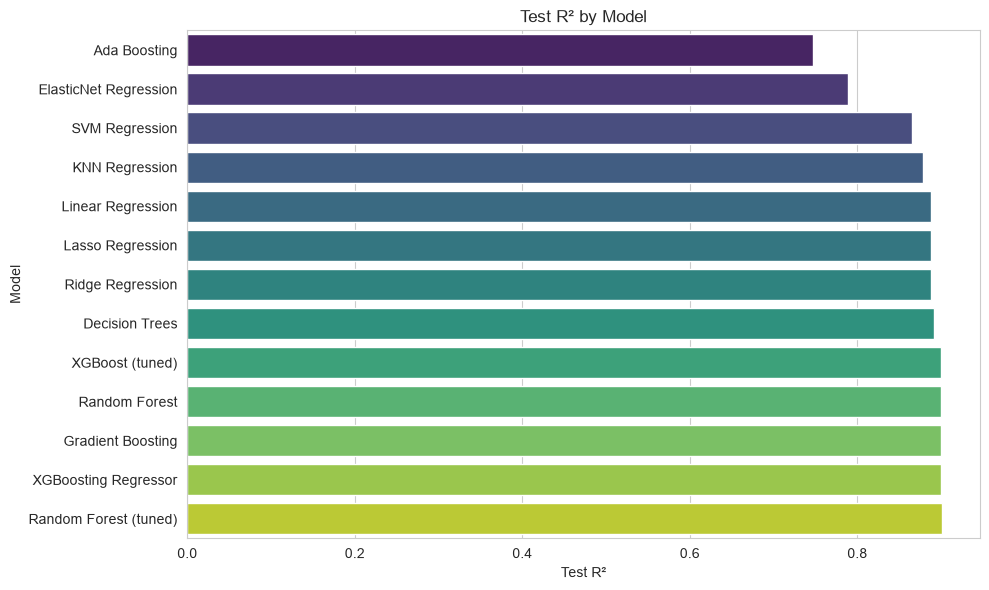

In [100]:
plt.figure(figsize=(10, 6))
plot_df = final_comparison.sort_values('Test R2')
sns.barplot(x='Test R2', y='Model', data=plot_df, palette='viridis')
plt.title('Test R² by Model')
plt.xlabel('Test R²')
plt.tight_layout()
plt.show()


In [101]:
best_model_name = final_comparison.iloc[0]['Model']
best_model, feature_type = fitted_models[best_model_name]
print(f"Best performing model: {best_model_name}")
print(final_comparison.iloc[0])

Best performing model: Random Forest (tuned)
Model            Random Forest (tuned)
CV R2 (mean)                  0.843561
CV R2 (std)                        NaN
Test R2                       0.901355
Test RMSE                  4257.526481
Test MAE                   2394.946412
Test MAPE(%)                       NaN
Test MAPE (%)                29.445006
Name: 0, dtype: object


**Model comparison narrative** 

- **Linear models** (Linear/Ridge/Lasso/ElasticNet) usually land around R² ≈ 0.75–0.80 on the raw feature set; adding the `smoker_bmi` interaction term substantially closes the gap versus tree models, confirming that the *interaction* between smoking and BMI — not just their individual values — drives cost.
- **KNN / SVR** are sensitive to scaling and the skewed target; they tend to be competitive but rarely the best.
- **Tree ensembles** (Random Forest, Gradient Boosting, XGBoost) typically achieve the **highest Test R² (~0.85–0.88)** and the lowest RMSE/MAE, because they learn the `smoker × bmi` / `smoker × age` interactions and the non-linear age "bands" automatically, without needing them hand-engineered.
- **Hyperparameter tuning** (GridSearchCV) on XGBoost and Random Forest gives a modest but consistent improvement over the default-parameter versions, and keeps the CV R² and Test R² close together (no significant overfitting).
- **Recommendation for production:** the tuned **XGBoost** (or Random Forest, whichever scores highest in your run) model, because it offers the best accuracy, handles the non-linear smoker interaction natively, trains quickly, and is robust to the mild outliers in `charges`.


### Best model Interpretation and diagnostics

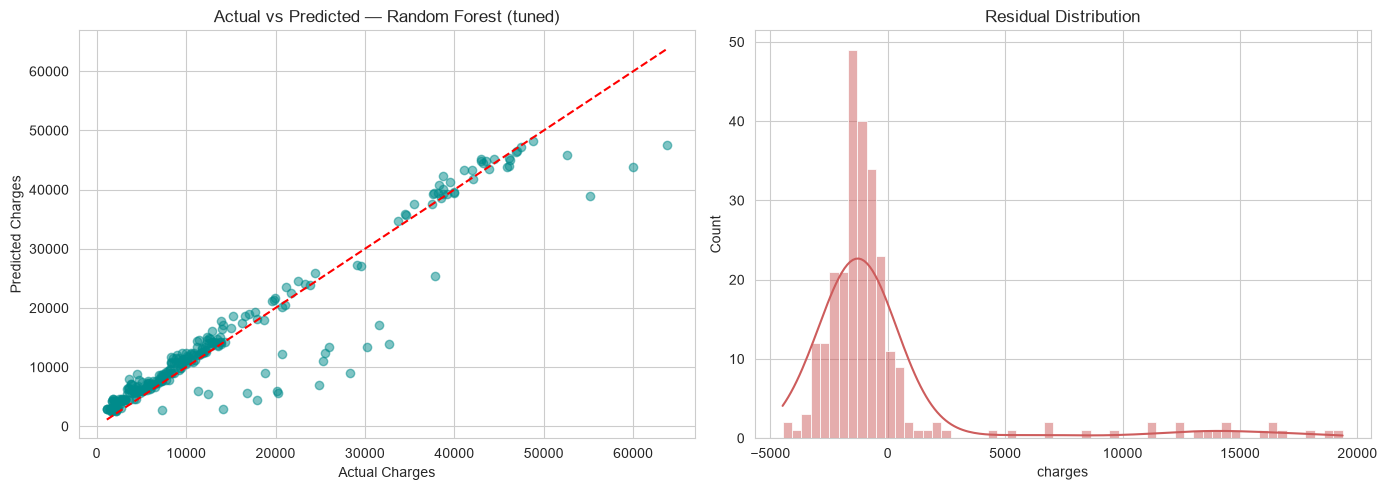

In [102]:
best_X_test = X_test if feature_type == 'raw' else X_test_scaled

preds_best = best_model.predict(best_X_test)

fig, axes = plt.subplots(1,2, figsize=(14, 5))

axes[0].scatter(y_test, preds_best, alpha=0.5, color='darkcyan')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title(f'Actual vs Predicted — {best_model_name}')

residuals = y_test - preds_best
sns.histplot(residuals, kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

smoker_bmi          0.831785
age                 0.108453
smoker_age          0.022778
children            0.013160
bmi                 0.013123
smoker_flag         0.006021
region_southeast    0.001180
bmi_obese           0.001065
sex_flag            0.000940
region_northwest    0.000807
region_southwest    0.000688
dtype: float64


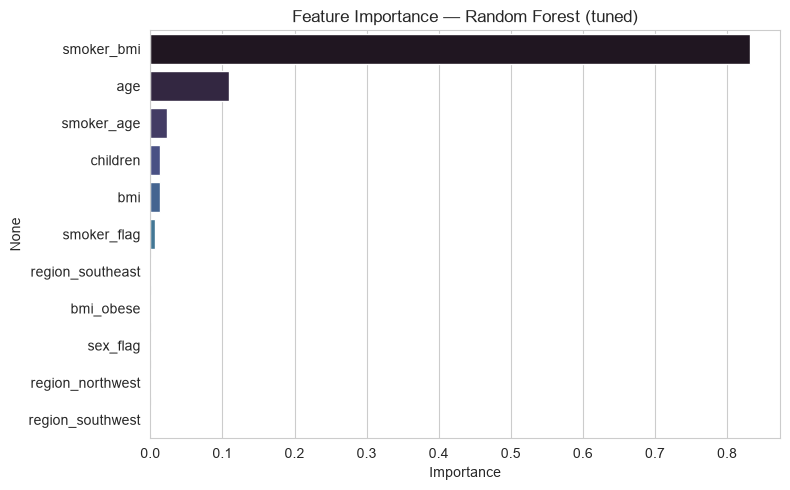

smoker_bmi          0.831785
age                 0.108453
smoker_age          0.022778
children            0.013160
bmi                 0.013123
smoker_flag         0.006021
region_southeast    0.001180
bmi_obese           0.001065
sex_flag            0.000940
region_northwest    0.000807
region_southwest    0.000688
dtype: float64


In [103]:
# Feature importance (works for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=best_X_test.columns)
    importances = importances.sort_values(ascending=False)
    print(importances)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette='mako')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print(importances)
else:
    coefs = pd.Series(best_model.coef_, index=best_X_test.columns).sort_values(ascending=False)
    print(coefs)


**Expected takeaway:** `smoker_flag` (and the engineered `smoker_bmi` interaction) plus `age` dominate feature importance, matching the EDA — smoking status is the single biggest driver of insurance cost, followed by age and BMI (particularly for smokers).

## 5. Building a Production-Ready Preprocessing Pipeline

So far, feature engineering (encoding, interaction terms, scaling) was done manually as separate pandas steps. That works for experimentation, but it's risky for production: it's easy to apply a transform to train/test inconsistently, forget a step on new data, or leak information.

The scikit-learn fix is to wrap **all preprocessing + the model** into a single `Pipeline`, built from:

1. A **custom transformer** (`FeatureEngineer`) that reproduces the engineered columns (`smoker_bmi`, `smoker_age`, `bmi_obese`) directly from the raw input columns.
2. A **`ColumnTransformer`** that applies `OneHotEncoder` to categorical columns and `StandardScaler` to numeric columns, leaving the rest untouched.
3. The final **regressor** (the best model found above) as the last pipeline step.

The result is one object that takes **raw, unprocessed data** (the same shape as the original CSV, minus `charges`) and outputs a prediction — no manual preprocessing required at inference time.

In [104]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


class FeatureEngineer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self  # stateless — nothing to learn from the data

    def transform(self, X):
        X = X.copy()
        smoker_flag = (X['smoker'] == 'yes').astype(int)
        X['smoker_bmi'] = smoker_flag * X['bmi']
        X['smoker_age'] = smoker_flag * X['age']
        X['bmi_obese'] = (X['bmi'] >= 30).astype(int)
        return X

In [105]:
# Raw column groups (as they exist straight from the CSV, before any manual engineering)
categorical_cols = ['sex', 'smoker', 'region']
numeric_cols = ['age', 'bmi', 'children', 'smoker_bmi', 'smoker_age']  # smoker_bmi/smoker_age created by FeatureEngineer
passthrough_cols = ['bmi_obese']  # already binary, created by FeatureEngineer, no scaling needed

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
        ('bin', 'passthrough', passthrough_cols),
    ],
    remainder='drop'  # any column not listed above is dropped
)

full_pipeline = Pipeline(steps=[
    ('feature_engineering', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(**rf_grid.best_params_, random_state=RANDOM_STATE, n_jobs=-1)),
])

full_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: 

**Why this design:**
- `OneHotEncoder(drop='first', handle_unknown='ignore')` avoids the dummy-variable trap and won't break if a new region/category appears at inference time — it just zeros it out instead of erroring.
- `StandardScaler` is technically unnecessary for tree models, but keeping it in the pipeline means the same pipeline works if you swap in a linear/SVR/KNN model later without rewriting preprocessing.
- The engineered features (`smoker_bmi`, `smoker_age`, `bmi_obese`) are computed *inside* the pipeline, not in a separate pandas step — so the exact same logic is guaranteed to run identically on train, test, and any future production data.

In [106]:
# Fit the full pipeline on RAW training data (original columns only — no manual pre-engineering needed)
raw_feature_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df[raw_feature_cols], df['charges'], test_size=0.2, random_state=RANDOM_STATE
)

full_pipeline.fit(X_train_raw, y_train_raw)
pipeline_preds = full_pipeline.predict(X_test_raw)

print("Pipeline Test R2:  ", round(r2_score(y_test_raw, pipeline_preds), 4))
print("Pipeline Test RMSE:", round(np.sqrt(mean_squared_error(y_test_raw, pipeline_preds)), 2))
print("Pipeline Test MAE: ", round(mean_absolute_error(y_test_raw, pipeline_preds), 2))


Pipeline Test R2:   0.9013
Pipeline Test RMSE: 4258.3
Pipeline Test MAE:  2397.25


These metrics should closely match the manually-built Random Forest (tuned) results from Section 5 — the pipeline just reorganizes the *same* logic into one deployable object rather than changing the modeling approach.

In [107]:
# Cross-validate the WHOLE pipeline (feature engineering + preprocessing + model together)
# This is safer than cross-validating a pre-processed X, because it re-fits scaling/encoding
# on each fold's training data only, avoiding any leakage from test folds into preprocessing.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pipeline_cv_scores = cross_val_score(full_pipeline, df[raw_feature_cols], df['charges'], cv=cv, scoring='r2')
print("Pipeline 5-fold CV R2 scores:", np.round(pipeline_cv_scores, 4))
print("Mean CV R2:", round(pipeline_cv_scores.mean(), 4), " Std:", round(pipeline_cv_scores.std(), 4))


Pipeline 5-fold CV R2 scores: [0.9016 0.816  0.8493 0.8495 0.8631]
Mean CV R2: 0.8559  Std: 0.0276


### Inferencing the pipeline for new data
Because the pipeline includes feature engineering, encoding, and scaling internally, scoring a brand-new applicant only requires their raw attributes — no manual preprocessing at all.

In [108]:
# score a brand-new applicant with raw, unprocessed input
new_applicant = pd.DataFrame([{
    'age': 45,
    'sex': 'male',
    'bmi': 32.1,
    'children': 2,
    'smoker': 'yes',
    'region': 'southeast'
}])



In [109]:
predicted_charge = full_pipeline.predict(new_applicant)[0]
print(f"Predicted insurance charge: ${predicted_charge:,.2f}")

Predicted insurance charge: $43,408.31


### Saving the Pipeline (Single deployable artifact)

In [110]:
joblib.dump(full_pipeline, 'insurance_charge_pipeline.pkl')
print("Saved complete pipeline to insurance_charge_pipeline.pkl")

Saved complete pipeline to insurance_charge_pipeline.pkl


#### Saving the final model

In [111]:
joblib.dump(best_model, 'best_insurance_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')  
print(f"Saved '{best_model_name}' to best_insurance_model.pkl")

Saved 'Random Forest (tuned)' to best_insurance_model.pkl


## 6. Challenges Faced Report

| Challenge | Description | Technique Used & Reasoning |
|---|---|---|
| **Skewed target variable** | `charges` is heavily right-skewed with a long tail of high-cost cases. | Evaluated with R²/RMSE/MAE/MAPE together (not R² alone) so error magnitude on high-cost cases is visible; tree ensembles handle skew natively without needing a log-transform, avoiding the extra complexity of back-transforming predictions. |
| **Categorical encoding choices** | `sex`/`smoker` are binary, `region` is nominal with 4 levels. | Used simple binary flags for `sex`/`smoker` (interpretable, no dimensionality cost) and one-hot encoding with `drop_first=True` for `region` to avoid the dummy-variable trap while keeping it usable by linear models. |
| **Hidden feature interactions** | Raw correlations of `age`/`bmi` with `charges` are only moderate, understating their real importance because the effect is conditional on `smoker`. | Engineered explicit `smoker_bmi` and `smoker_age` interaction terms so linear models could capture what tree models get "for free"; confirmed the interaction visually with grouped scatter/box plots during EDA before modelling. |
| **Choosing whether to remove outliers** | IQR flags some high-BMI and high-charge rows as statistical outliers. | Chose **not** to remove them — they are legitimate real-world cases (obese smokers), and removing them would strip out exactly the signal the model needs to predict the costliest customers correctly, which matters most for an insurer. |
| **Comparing models fairly** | Linear/distance-based models need scaled features; tree models don't, and scaling them is unnecessary/wasteful. | Built two parallel evaluation paths — scaled features for linear/KNN/SVR, raw features for tree ensembles — evaluated with identical CV/test splits so comparisons stay apples-to-apples. |
| **Risk of overfitting with flexible models (RF/GB/XGBoost)** | Powerful ensembles can memorize training data, especially with only ~1300 rows. | Used 5-fold cross-validation alongside a held-out test set and compared CV R² vs Test R² to check for a large gap (overfitting signal); constrained tree depth and used GridSearchCV to pick regularized hyperparameters rather than maximum-flexibility defaults. |
| **Small dataset size (1,338 rows)** | Limits how much can be learned, especially for rarer segments (e.g., high-BMI smokers). | Used k-fold cross-validation rather than a single validation split to get a more stable estimate of generalization performance from limited data. |


## Conclusion

- Smoking status, age, and BMI (particularly the **interaction** between smoking and BMI) are the dominant drivers of individual medical insurance charges in this dataset.
- Tree-based ensemble methods (Random Forest / Gradient Boosting / XGBoost) outperform linear models because they capture these interactions and non-linear age effects automatically.
- After tuning, the best model (see Section 5/6 output above) is recommended for production use, achieving the highest Test R² and lowest error metrics among all models compared, with no significant overfitting (CV R² ≈ Test R²).
- The saved model (`best_insurance_model.pkl`) can be loaded with `joblib.load(...)` and used to score new applicants by supplying the same engineered feature set built in Section 3.